In [9]:
# R2_CAR171_Canopus.ipynb
# Estimating the stray-light for the Commissioning Activity Request (CAR) 171 observations. 
# This notebook is based on the R1_Rosalia_stray_example.ipynb notebook, but it is adapted to the specific case of Canopus.
# - Alejandro S. Borlaff / NASA Ames / a.s.borlaff@nasa.gov. March 11, 2026.
import os
import rosalia as rs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.time import Time
import astropy.units as u
from astropy.coordinates import SkyCoord
from astroquery.simbad import Simbad
print("ROSALIA version:", rs.__version__)
plt.style.use(os.path.dirname(rs.__file__) + "/style/nature_style.mplstyle")

ROSALIA version: 1.1.0


In [10]:
# Let's find Canopus (alpha Carinae), Eta Uma, and HD128998, the stars selected for CAR171.
# These stars are in the continuous viewing zone of Roman. Canopus is the second brightest star in the sky.

# Find the Calibration Stars. 
alfCar = Simbad.query_object('Canopus')
ra_alfCar = alfCar["ra"][0]
dec_alfCar = alfCar["dec"][0]

etaUma = Simbad.query_object('Eta Uma')
ra_etaUma = etaUma["ra"][0]
dec_etaUma = etaUma["dec"][0]

HD = Simbad.query_object('HD128998')
ra_HD = HD["ra"][0]
dec_HD = HD["dec"][0]



# Test
target = SkyCoord(ra_alfCar*u.deg, dec_alfCar*u.deg, frame="icrs")

date = Time('2026-07-01T00:00:00.0', format='isot', scale='utc')

offset_pointing = rs.telescopes.Roman.find_wfi_center_for_offset_target(ra_target=ra_alfCar,
                                                      dec_target=dec_alfCar,
                                                      mjd=date.mjd,
                                                      dX=1, dY=1)

In [11]:
# Equatorial pole Test
from astropy.coordinates import get_body
date = Time('2026-07-01T00:00:00.0', format='isot', scale='utc')

sun_coord = get_body('Sun', date)   # get coordinate object for the Sun for each day of the year

ecliptic_pole = SkyCoord(0*u.deg, 89*u.deg, frame="barycentricmeanecliptic")
ecliptic_pole = ecliptic_pole.transform_to("icrs")
bestPA_for_canopus_Dec26 = rs.telescopes.Roman.get_bestPA(ra=ra_alfCar, dec=dec_alfCar, mjd=date.mjd)
print(bestPA_for_canopus_Dec26)
offset_pointing = rs.telescopes.Roman.find_wfi_center_for_offset_target(ra_target=ecliptic_pole.ra.degree,
                                                      dec_target=ecliptic_pole.dec.degree,
                                                      mjd=date.mjd,
                                                      dX=0, dY=0)
print(offset_pointing)
print(sun_coord.barycentricmeanecliptic)

3.433914460691109
{'ra_wficen': np.float64(272.51260008821055), 'dec_wficen': np.float64(66.54059930452142), 'PA_WFI_offset': np.float64(-66.52387659834767), 'V3PA_offset': np.float64(-6.523876598347677), 'V3PA_origin': np.float64(-6.523876598347678)}
<SkyCoord (BarycentricMeanEcliptic: equinox=J2000.000): (lon, lat, distance) in (deg, deg, AU)
    (251.19460248, 1.08182274, 0.00564382)>


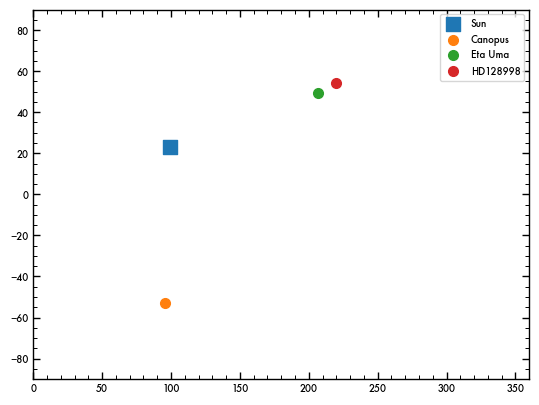

In [12]:
sun_ra = sun_coord.ra.degree
sun_dec = sun_coord.dec.degree
plt.scatter(sun_ra, sun_dec, marker="s", s=100, label="Sun")
plt.scatter(ra_alfCar, dec_alfCar, marker="o", label = "Canopus")
plt.scatter(ra_etaUma, dec_etaUma, marker="o", label = "Eta Uma")
plt.scatter(ra_HD, dec_HD, marker="o", label = "HD128998")
plt.xlim((0,360))
plt.ylim((-90,90))
plt.legend()

In [13]:
CAR171 = pd.read_csv("CAR171_v2_coordinates.csv")
# These are the coordinates of specially sensitive locations 
# for stray-light, measured in offset degrees from the center of WFI focal plane
dX = CAR171["MPA_ThetaX"]
dY = CAR171["MPA_ThetaY"]
CAR171["RA_Source"] = 9999.
CAR171["Dec_Source"] = 9999.
CAR171.at[12:,"RA_Source"] = ra_alfCar
CAR171.at[12:,"Dec_Source"] = dec_alfCar
CAR171.at[12:,"Target source"] = "Canopus"
CAR171.at[0:4, "RA_Source"] = ra_etaUma
CAR171.at[0:4,"Dec_Source"] = dec_etaUma
CAR171.at[0:4,"Target source"] = "EtaUma"
CAR171.at[4:6,"RA_Source"] = ra_HD
CAR171.at[4:6,"Dec_Source"] = dec_HD
CAR171.at[4:6,"Target source"] = "HD128998"
CAR171.at[6:10,"RA_Source"] = ra_etaUma
CAR171.at[6:10,"Dec_Source"] = dec_etaUma
CAR171.at[6:10,"Target source"] = "EtaUma"
CAR171.at[10:11,"RA_Source"] = ra_HD
CAR171.at[10:11,"Dec_Source"] = dec_HD
CAR171.at[10:11,"Target source"] = "HD128998"

CAR171["MA Table"] = "IM_XXX_XX"
CAR171.at[0:11, "MA Table"] = "IM_171_10"
CAR171.at[12:,  "MA Table"] = "IM_193_11"

CAR171["Resultant"] = 9999
CAR171.at[0:11, "Resultant"] = 10
CAR171.at[12:,  "Resultant"] = 11

CAR171[0:16]

,Unnamed: 0,Activity name,CAR,Region,Lite?,Possible descope,MPA_ThetaX,MPA_ThetaY,Target source,N_FRAME,N_EXP,N_FILT,Time,Filter(s),Notes,RA_Source,Dec_Source,MA Table,Resultant
0,0,SCA14_vertical,171.1,Outer PSF,True,False,0.2730,0.1149,EtaUma,55,2,1,8.8,F158,Risk reduction,206.885157,49.313267,IM_171_10,10
1,1,SCA14_horizontal,171.1,Outer PSF,True,False,0.2044,0.1480,EtaUma,55,2,1,8.8,F158,Risk reduction,206.885157,49.313267,IM_171_10,10
2,2,SCA5_vertical,171.1,Outer PSF,True,False,-0.2713,0.1151,EtaUma,55,2,1,8.8,F158,Risk reduction,206.885157,49.313267,IM_171_10,10
3,3,SCA5_horizontal,171.1,Outer PSF,True,False,-0.2026,0.1481,EtaUma,55,2,1,8.8,F158,Risk reduction,206.885157,49.313267,IM_171_10,10
4,4,SCA14_cen,171.1,Inner PSF,True,False,0.2044,0.0823,HD128998,55,2,1,8.8,F158,Risk reduction,219.563423,54.023340,IM_171_10,10
5,5,SCA5_cen,171.1,Inner PSF,True,False,-0.2027,0.0825,HD128998,55,2,1,8.8,F158,Risk reduction,219.563423,54.023340,IM_171_10,10
6,6,SCA14_vertical,171.1,Outer PSF,True,False,0.2730,0.1149,EtaUma,55,2,8,47.3,Each,Each filter to look for ghosts,206.885157,49.313267,IM_171_10,10
7,7,SCA14_horizontal,171.1,Outer PSF,True,False,0.2044,0.1480,EtaUma,55,2,8,47.3,Each,NaN,206.885157,49.313267,IM_171_10,10
8,8,SCA5_vertical,171.1,Outer PSF,True,False,-0.2713,0.1151,EtaUma,55,2,8,47.3,Each,NaN,206.885157,49.313267,IM_171_10,10
9,9,SCA5_horizontal,171.1,Outer PSF,True,False,-0.2026,0.1481,EtaUma,55,2,8,47.3,Each,NaN,206.885157,49.313267,IM_171_10,10


In [14]:
# ra_source = CAR171["RA_Source"]
# dec_source = CAR171["Dec_Source"]
number_of_points_of_interest = len(dX)

# To measure the stray-light from those sources, we need to place the center 
# of Roman / WFI at a certain distance and position angle from the source 
# that generates the stray-light. We will name that source the "offending" source. 

# ROSALIA has a specific tool to compute those locations. 

# The optimal position angle of Roman depends with time. 
# Let's set an approximate time for the Commissioning Activities
date = Time('2026-12-01T00:00:00.0', format='isot', scale='utc')

ra_wfi = np.zeros(number_of_points_of_interest)
dec_wfi = np.zeros(number_of_points_of_interest)
V3PA_ori = np.zeros(number_of_points_of_interest)
V3PA_off = np.zeros(number_of_points_of_interest)
WFIPA_off = np.zeros(number_of_points_of_interest)

activity_name_apt = []
category = []
description = []
for i in range(number_of_points_of_interest):
    offset_pointing = rs.telescopes.Roman.find_wfi_center_for_offset_target(ra_target=CAR171["RA_Source"].iloc[i],
                                                      dec_target=CAR171["Dec_Source"].iloc[i],
                                                      mjd=date.mjd,
                                                      dX=dX[i], dY=dY[i])
    ra_wfi[i] = offset_pointing["ra_wficen"]
    dec_wfi[i] = offset_pointing["dec_wficen"]
    WFIPA_off[i] = offset_pointing["PA_WFI_offset"]%360
    V3PA_off[i] = offset_pointing["V3PA_offset"]%360
    V3PA_ori[i] = offset_pointing["V3PA_origin"]%360
    # v3pa[i] = offset_pointing["PA_v3"] % 360
    activity_name_apt.append(CAR171["Activity name"].iloc[i]+"_"+str(i+1).zfill(3))
    category.append("Calibration")
    description.append("Stray light test")

car171_APT = pd.DataFrame({"Target": activity_name_apt, "ArchiveTarget": activity_name_apt,
                            "description":description, "category": category, "RA": ra_wfi, "DEC": dec_wfi, 
                           "WFIPA_off": WFIPA_off, "V3PA_off": V3PA_off, "V3PA_ori": V3PA_ori,
                           "CAR": CAR171["CAR"], "Region": CAR171["Region"], "Target_Source": CAR171["Target source"],
                           "RA_Source": CAR171["RA_Source"],"Dec_Source": CAR171["Dec_Source"],
                           "MPA_ThetaX": CAR171["MPA_ThetaX"], "MPA_ThetaY": CAR171["MPA_ThetaY"], 
                           "N_FRAME": CAR171["N_FRAME"], "N_EXP": CAR171["N_EXP"], "N_FILT": CAR171["N_FILT"], "Filter": CAR171["Filter(s)"],
                           "MA Table": CAR171["MA Table"], "Resultant": CAR171["Resultant"]})
car171_APT.to_csv("CAR171_apt_targets.csv")


KeyboardInterrupt: 

In [ ]:
car171_APT[0:1]

,Target,ArchiveTarget,description,category,RA,DEC,WFIPA_off,V3PA_off,V3PA_ori,CAR,...,RA_Source,Dec_Source,MPA_ThetaX,MPA_ThetaY,N_FRAME,N_EXP,N_FILT,Filter,MA Table,Resultant
0,SCA14_vertical_001,SCA14_vertical_001,Stray light test,Calibration,206.763704,49.027915,82.679537,142.679537,142.770046,171.1,...,206.885157,49.313267,0.273,0.1149,55,2,1,F158,IM_171_10,10


ROSALIA Stray-light Mapper: Scanning ... 
 ████████                                     ████████ 
 ████████ ████████                   ████████ ████████ 
 ████████ ████████ ████████ ████████ ████████ ████████ 
 ████████ ████████ ████████ ████████ ████████ ████████ 
 ████████ ████████ ████████ ████████ ████████ ████████ 
 ████████ ████████ ████████ ████████ ████████ ████████ 
 ████████ ████████ ████████ ████████ ████████ ████████ 
 ████████ ████████ ████████ ████████ ████████ ████████ 
 ████████ ████████ ████████ ████████ ████████ ████████ 
 ████████ ████████ ████████ ████████ ████████ ████████ 
 ████████ ████████ ████████ ████████ ████████ ████████ 
 ████████ ████████ ████████ ████████ ████████ ████████ 
          ████████ ████████ ████████ ████████          
                   ████████ ████████                   



18it [00:58,  3.27s/it]


SCA 18 - Subarray X=17.92 - Subarray Y=17.92
SCA 18 out of 18: 98.44% completed
2026-05-29T16:46:36.800915: Done


18it [00:00, 490.92it/s]
18it [00:00, 512.72it/s]


Output saved in: /Users/aborlaff/NASA/ROSALIA/notebooks/CAR171/CAR171_SCA5_horizontal_WFI_F158_RA_206.620_DEC_049.495_MJD_61375.00000_PA_082.57_stray.fits
Generating ROSALIA summary report...
















100%|██████████| 18/18 [00:58<00:00,  3.23s/it]


KeyError: Header keyword not found
KeyError: Header keyword not found
KeyError: Header keyword not found
KeyError: Header keyword not found
/Users/aborlaff/NASA/ROSALIA/notebooks/CAR171/CAR171_SCA5_horizontal_WFI_F158_RA_206.620_DEC_049.495_MJD_61375.00000_PA_082.57_stray_drz.fits
/Users/aborlaff/NASA/ROSALIA/notebooks/CAR171/CAR171_SCA5_horizontal_WFI_F158_RA_206.620_DEC_049.495_MJD_61375.00000_PA_082.57_stray_drz_scaled.fits
/Users/aborlaff/NASA/ROSALIA/notebooks/CAR171/CAR171_SCA5_horizontal_WFI_F158_RA_206.620_DEC_049.495_MJD_61375.00000_PA_082.57_stray_drz_scaled.fits
/Users/aborlaff/NASA/ROSALIA/notebooks/CAR171/CAR171_SCA5_horizontal_WFI_F158_RA_206.620_DEC_049.495_MJD_61375.00000_PA_082.57_stray_drz_scaled.fits
/Users/aborlaff/NASA/ROSALIA/notebooks/CAR171/CAR171_SCA5_horizontal_WFI_F158_RA_206.620_DEC_049.495_MJD_61375.00000_PA_082.57_stray_main_off.fits
/Users/aborlaff/NASA/ROSALIA/notebooks/CAR171/CAR171_SCA5_horizontal_WFI_F158_RA_206.620_DEC_049.495_MJD_61375.00000_PA_082.

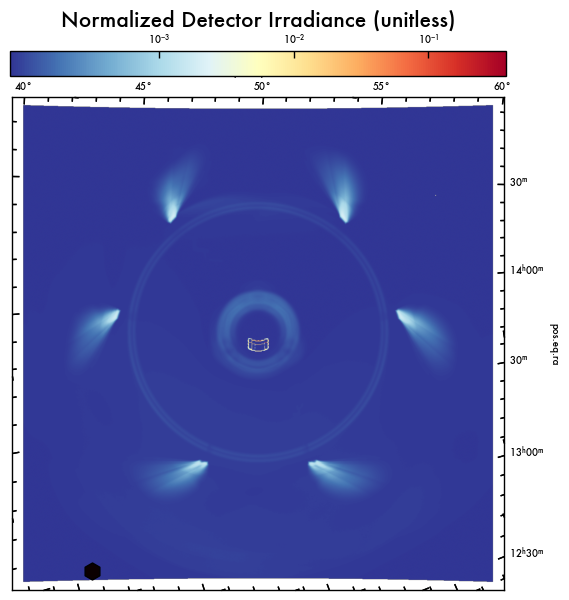

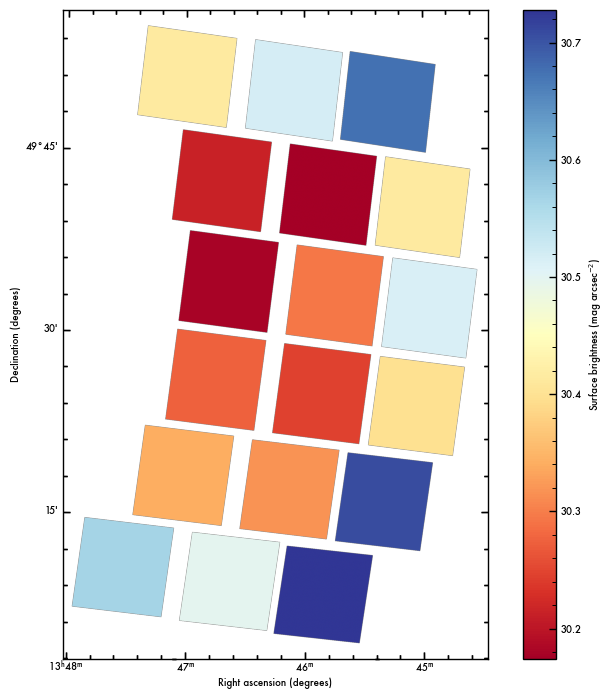

Plot: Stray-light surface brightness flux.
0.00024118341505527502
0.00040160965174436576


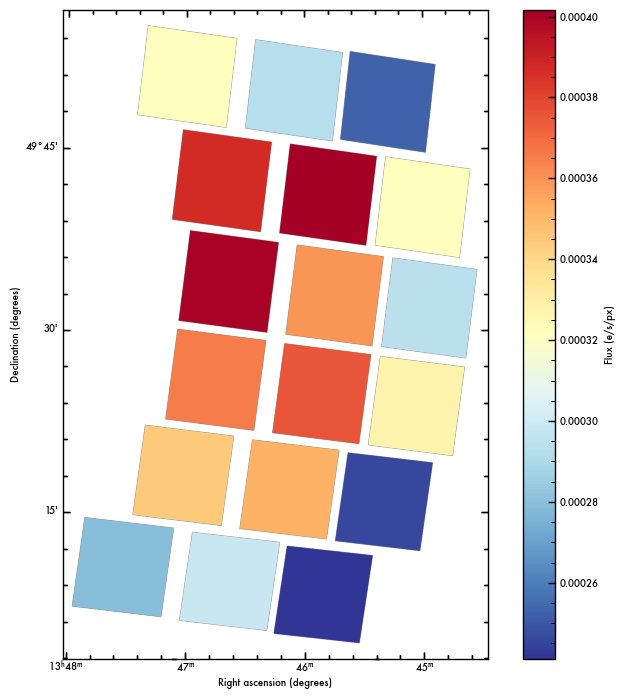

Plot: Main offender map.
1.0
1.0
Unique IDs:
[1]
Unique IDs with counts > 1:
[1]
* eta UMa
Main stray-light offenders:

100.00% - (206.89, 49.31), m=3.00 - * eta UMa


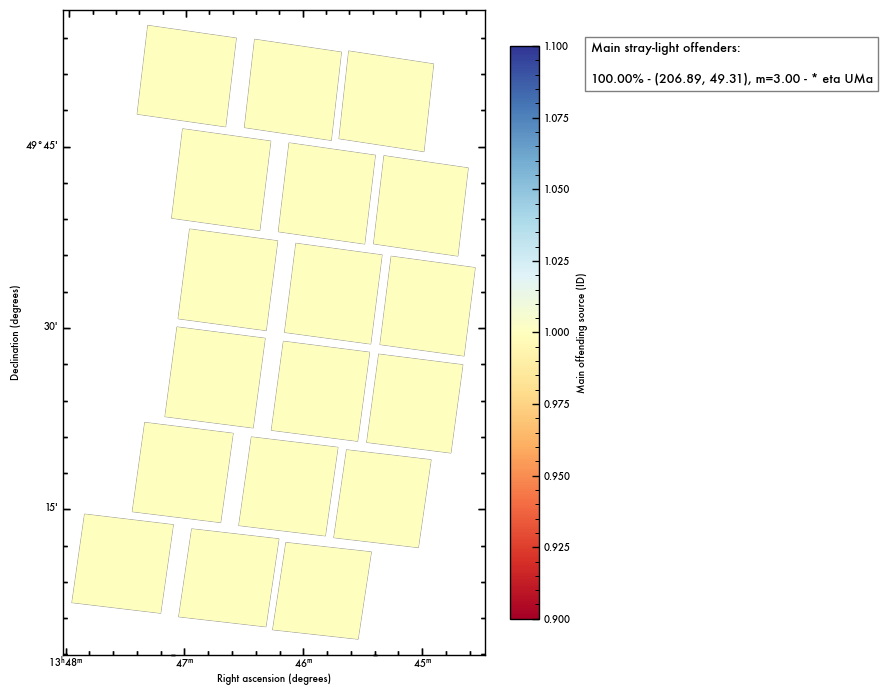

Plot: Source environment map.
Plot: Location of Main offenders on NDI map.
Unique IDs:
[1]
Unique IDs with counts > 1:
[1]
* eta UMa
Main stray-light offenders:

100.00% - (206.89, 49.31), m=3.00 - * eta UMa
WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN'
CUNIT : 'deg' 'deg'
CRVAL : 206.61969549841064 49.49531373303607
CRPIX : 636.5 636.5
NAXIS : 1273  1273


/Users/aborlaff/NASA/ROSALIA/notebooks/CAR171/CAR171_SCA14_cen_WFI_F158_RA_219.397_DEC_053.826_MJD_61375.00000_PA_094.34.fits
Setting to None
Setting to None
Setting to None
Setting to None
Setting to None
Setting to None
Setting to None
Setting to None
Setting to None
BUNIT not found!
> Image mode:/Users/aborlaff/NASA/ROSALIA/notebooks/CAR171/CAR171_SCA14_cen_WFI_F158_RA_219.397_DEC_053.826_MJD_61375.00000_PA_094.34.fits
Setting to None
Setting to None
Setting to None
Setting to None
Setting to None
Setting to None
Setting to None
Setting to None
Setting to None
BUNIT not found!











KeyboardInterrupt: 

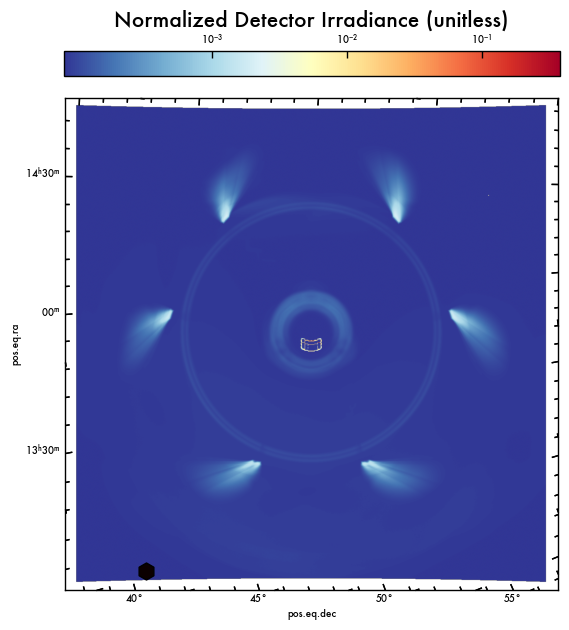

In [ ]:

# if True:
for i in range(len(ra_wfi)):
    #i = 0
    ra = car171_APT["RA"].iloc[i] # ra_wfi[i]
    dec = car171_APT["DEC"].iloc[i] # dec_wfi[i]
    pa = car171_APT["WFIPA_off"].iloc[i] # WFIPA_off[i]
    mjd = date.mjd
    bandpass="F158"
    exptime=192

    if car171_APT["Target_Source"].iloc[i] == "Canopus":
        mag_star = -0.74
    if car171_APT["Target_Source"].iloc[i] == "EtaUma":
        mag_star = 3
    if car171_APT["Target_Source"].iloc[i] == "HD128998":
        mag_star = 6.75

    import pandas as pd
    star_catalog = pd.DataFrame({"ra": car171_APT["RA_Source"].iloc[i], 
                                "dec": car171_APT["Dec_Source"].iloc[i] , 
                                "source_id": car171_APT["Target_Source"].iloc[i], 
                                "cat_id": 1,
                                "mag_lambda": mag_star}, index=[0])

    rosalia_stray = rs.correct.rosalia_stray(ra=ra, dec=dec, prefix="CAR171_" + CAR171["Activity name"].iloc[i] + "_",
                                             PA=pa, date=date, bandpass=bandpass, 
                                             exptime=exptime, radius=1, catalog=star_catalog,
                                             g_mag_max=17, verbose=3)

In [ ]:
# For the Dragon's Breath example, let's change the target to a dimmer star. 
# Magnitude 2 star. 

# Let's find Canopus (alpha Carinae), the star selected for CAR171. 
# This star is in the continuous viewing zone of Roman, and it is the second brightest star in the sky.
import astropy.units as u
from astroquery.simbad import Simbad
from astropy.coordinates import SkyCoord

alfUrsae = Simbad.query_object('Mizar')
ra_star = alfUrsae["ra"][0]
dec_star = alfUrsae["dec"][0]

target = SkyCoord(ra_star*u.deg, dec_star*u.deg, frame="icrs")
print(target)

# These are the coordinates of specially sensitive locations 
# for stray-light, measured in offset degrees from the center of WFI focal plane
dX = np.array([-0.0688, 0.0688, -0.138, 0.138])
dY = np.array([-0.0312-20/60/60, -0.0312, -0.0035, -0.0048])
number_of_points_of_interest = len(dX)


# To measure the stray-light from those sources, we need to place the center 
# of Roman / WFI at a certain distance and position angle from the source 
# that generates the stray-light. We will name that source the "offending" source. 

# ROSALIA has a specific tool to compute those locations. 

# The optimal position angle of Roman depends with time. 
# Let's set an approximate time for the Commissioning Activities
from astropy.time import Time
date = Time('2026-11-21T00:00:00.0', format='isot', scale='utc')

ra_wfi = np.zeros(number_of_points_of_interest)
dec_wfi = np.zeros(number_of_points_of_interest)
pa_wfi = np.zeros(number_of_points_of_interest)

for i in range(number_of_points_of_interest):
    offset_pointing = rs.telescopes.Roman.find_wfi_center_for_offset_target(ra_target=target.ra.degree,
                                                      dec_target=target.dec.degree,
                                                      mjd=date.mjd,
                                                      dX=dX[i], dY=dY[i])
    ra_wfi[i] = offset_pointing["ra_wficen"]
    dec_wfi[i] = offset_pointing["dec_wficen"]
    pa_wfi[i] = offset_pointing["pa_wfi"]
